In [5]:
import pandas as pd
import numpy as np

In [6]:
input1 = r"C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\input\축1_results.csv"
input2 = r"C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\input\축2_results.csv"
input3 = r"C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\input\축3_results.csv"
input4 = r"C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\input\축4_results.csv"
output_path = r"C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\final_output\final_result_hybrid.csv"

In [7]:
df1 = pd.read_csv(input1)
df2 = pd.read_csv(input2)
df3 = pd.read_csv(input3)
df4 = pd.read_csv(input4)

df1 = df1[["pklt_nm", "final_score"]].copy()
df2 = df2[["pklt_nm", "total_score"]].copy()
df3 = df3[["pklt_nm", "축3_자가소비적합성"]].copy()
df4 = df4[["pklt_nm", "공공편익점수"]].copy()

df_all = df1.merge(df2, on='pklt_nm', how='inner').merge(df3, on='pklt_nm', how='inner').merge(df4, on='pklt_nm', how='inner')
df_all.rename(columns={'final_score': '축1_score','total_score': '축2_score', '축3_자가소비적합성': '축3_score', '공공편익점수': '축4_score'}, inplace=True)

df_all.head()

,pklt_nm,축1_score,축2_score,축3_score,축4_score
0,15-가600구간,0.943604,0.714687,0.470141,0.158375
1,21-37,0.972298,0.717799,0.807012,0.246208
2,BYC,0.874950,0.324820,0.228710,0.433444
3,KBS별관뒤 노상주차장,0.830517,0.395530,0.109826,0.592532
4,KBS별관옆 노상주차장,0.830517,0.395530,0.109826,0.592532


In [8]:
features = ['축1_score', '축2_score', '축3_score', '축4_score']

#AHP 결합 방식
matrix = np.array([
    [  1,      3,      5,     7  ], # 태양광 (유휴보다 3배, 전기보다 5배, 복지보다 7배 중요)
    [ 1/3,     1,      2,     4  ], # 유휴공간 (전기보다 2배, 복지보다 4배 중요)
    [ 1/5,    1/2,     1,     2  ], # 전기 활용 (유휴보다는 덜 중요(1/2), 복지보다 2배 중요)
    [ 1/7,    1/4,    1/2,    1  ]  # 복지 활용 (가장 후순위)
])

col_sums = matrix.sum(axis=0)
ahp_weights = (matrix / col_sums).mean(axis=1)

In [9]:
# 엔트로피 계산 -> 데이터 분산 반영
X = df_all[features].values

# 0이 있으면 log 계산 시 에러가 나므로 아주 작은 값(epsilon)을 더해줍니다.
epsilon = 1e-9
X_safe = np.where(X == 0, epsilon, X)

# 1) 각 데이터가 전체 합에서 차지하는 비율(Proportion) 계산
P = X_safe / X_safe.sum(axis=0)

# 2) 엔트로피(E_j) 계산
n = len(df_all) # 데이터(주차장) 개수
k = 1 / np.log(n)
E = -k * np.sum(P * np.log(P), axis=0)

# 3) 정보 유용성(d_j = 1 - E) 및 최종 엔트로피 가중치 산출
d = 1 - E
entropy_weights = d / d.sum()

In [10]:
hybrid_raw = ahp_weights * entropy_weights
hybrid_weights = hybrid_raw / hybrid_raw.sum()

# 결과 출력
for i, name in enumerate(features):
    print(f"[{name}]")
    print(f" - AHP 가중치 (주관): {ahp_weights[i]:.4f}")
    print(f" - 엔트로피 가중치(객관): {entropy_weights[i]:.4f}")
    print(f" => ★최종 하이브리드 가중치★: {hybrid_weights[i]:.4f}\n")

[축1_score]
 - AHP 가중치 (주관): 0.5791
 - 엔트로피 가중치(객관): 0.1411
 => ★최종 하이브리드 가중치★: 0.4294

[축2_score]
 - AHP 가중치 (주관): 0.2326
 - 엔트로피 가중치(객관): 0.1222
 => ★최종 하이브리드 가중치★: 0.1494

[축3_score]
 - AHP 가중치 (주관): 0.1213
 - 엔트로피 가중치(객관): 0.5675
 => ★최종 하이브리드 가중치★: 0.3616

[축4_score]
 - AHP 가중치 (주관): 0.0670
 - 엔트로피 가중치(객관): 0.1692
 => ★최종 하이브리드 가중치★: 0.0596



In [11]:
#최종 지표 계산
df_all['final_hybrid_score'] = (
    df_all['축1_score'] * hybrid_weights[0] +
    df_all['축2_score'] * hybrid_weights[1] +
    df_all['축3_score'] * hybrid_weights[2] +
    df_all['축4_score'] * hybrid_weights[3]
)

final_cols = ['pklt_nm'] + features + ['final_hybrid_score']
df_final = df_all[final_cols].sort_values("final_hybrid_score", ascending = False).copy()
df_final

,pklt_nm,축1_score,축2_score,축3_score,축4_score,final_hybrid_score
645,천호역 공영주차장,0.993685,0.895253,0.881034,0.375164,0.901391
414,수서역북 공영주차장,0.971198,0.747934,0.917557,0.381170,0.883297
587,잠실역 공영주차장,0.989752,0.683379,0.931552,0.304781,0.882132
664,탄천제2호 공영주차장,0.962862,0.803705,0.911099,0.229461,0.876672
528,영희초교 공영주차장,0.962862,0.784282,0.911099,0.229461,0.873771
...,...,...,...,...,...,...
564,유경백화점뒤,0.161729,0.263228,0.151131,0.162483,0.173101
608,주공5단지옆,0.161729,0.262800,0.151131,0.162483,0.173037
455,신한증권옆,0.161729,0.262514,0.151131,0.162483,0.172994
652,청구건영아파트옆,0.161729,0.262514,0.151131,0.162483,0.172994


In [19]:
df_final.to_csv(
    output_path,
    index=False,
    encoding="utf-8-sig"
)

1위. 태양광 에너지: 약 57.8% (설치 목적 그 자체)

2위. 유휴공간 활용: 약 23.2% (설치를 위한 필수 물리적 제약조건)

3위. 전기 활용: 약 12.0% (생산된 전기의 사후 연계성)

4위. 복지 활용: 약 6.6% (공공 프로젝트로서의 부가 가치)

#### 이렇게 나올 수 있겠끔 ahp matirx로 가중치 계산했고, 이후에 데이터 분산은 엔트로피 계산으로 반영
#### -> 태양광이 가장 크게 나올 수 있겠끔 했지만, 이렇게 잡은 이유에 대해서 반드시 설명이 .. 필요할 듯

---

### 시각화1 - 서울시 지도+ 상위 입지 마킹

목적: 지역쏠림 패턴파악

구단위 지도를 그려야하는데 final_results_hybrid.csv에 구 칼럼이 없음

**전략**

1. 데이터 병합: final_result_hybrid.csv(점수)와 축3_results.csv(자치구 정보)를 pklt_nm을 기준으로 합침

2. 구 단위 집계: 합쳐진 데이터를 바탕으로 각 구의 평균 하이브리드 점수를 계산합니다.

3. 시각화: 구별 평균 점수는 배경(Choropleth)으로, 상위 13개 주차장은 강조된 버블로 표현합니다.

In [24]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import requests
import warnings

warnings.filterwarnings('ignore')

# ── 1. 데이터 로드 및 병합 (기본 로직 유지) ──────────────────
path_hybrid = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\final_output\final_result_hybrid.csv'
path_info = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\input\축3_results.csv'

df_hybrid = pd.read_csv(path_hybrid)
df_info = pd.read_csv(path_info)[['pklt_nm', '자치구', 'lot', 'lat']]
df_final = pd.merge(df_hybrid, df_info, on='pklt_nm', how='left')

gu_score = df_final.groupby('자치구')['final_hybrid_score'].mean().reset_index()

url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
geo = gpd.read_file(requests.get(url).text)
geo = geo.merge(gu_score, left_on='name', right_on='자치구', how='left')

# ── 2. 시각화 설정 ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 11))
fig.patch.set_facecolor('white')

# (1) 배경: 구 단위 코로플레스
vmin, vmax = gu_score['final_hybrid_score'].min(), gu_score['final_hybrid_score'].max()
geo.plot(ax=ax, column='final_hybrid_score', cmap='BuPu', 
         edgecolor='#DDDDDD', linewidth=0.5, alpha=0.3)

# 구 이름 표시
for _, row in geo.iterrows():
    if row.geometry is None: continue
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, row['name'], ha='center', va='center',
            fontproperties=font_prop, fontsize=8.5, color='#888888', alpha=0.7)

# (2) 상위 10개 입지 단일 빨간색 점 (테두리 없음)
top_10 = df_final.nlargest(10, 'final_hybrid_score')
ax.scatter(df_final['lot'], df_final['lat'], s=8, color='#EEEEEE', alpha=0.4, zorder=1)

ax.scatter(
    top_10['lot'], top_10['lat'],
    s=180, color='#FF0000', linewidths=0, edgecolors='none', alpha=0.9, zorder=10,
    label='최우선 설치 대상 (Top 10)'
)

# ── 3. 컬러바 크기 조정 및 배치 ────────────────────────────────
sm = cm.ScalarMappable(cmap='BuPu', norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])

# shrink: 1.0이 전체 높이, 값을 줄여서 길이를 조절 (0.4~0.5 권장)
# aspect: 컬러바의 폭 조절 (값이 클수록 가늘어짐)
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.04, shrink=0.5, aspect=25)
cbar.set_label('구 단위 평균 하이브리드 점수', fontproperties=font_prop, fontsize=9, labelpad=10)
cbar.ax.tick_params(labelsize=8)

# 일반 범례
ax.legend(prop=font_bold, loc='lower left', frameon=True, borderpad=1)

plt.title('서울시 종합 상위 입지 분포 패턴', 
          fontproperties=font_bold, fontsize=20, pad=25)

ax.set_axis_off()
plt.tight_layout()

save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_종합지도_컬러바조정.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

KeyError: '자치구'

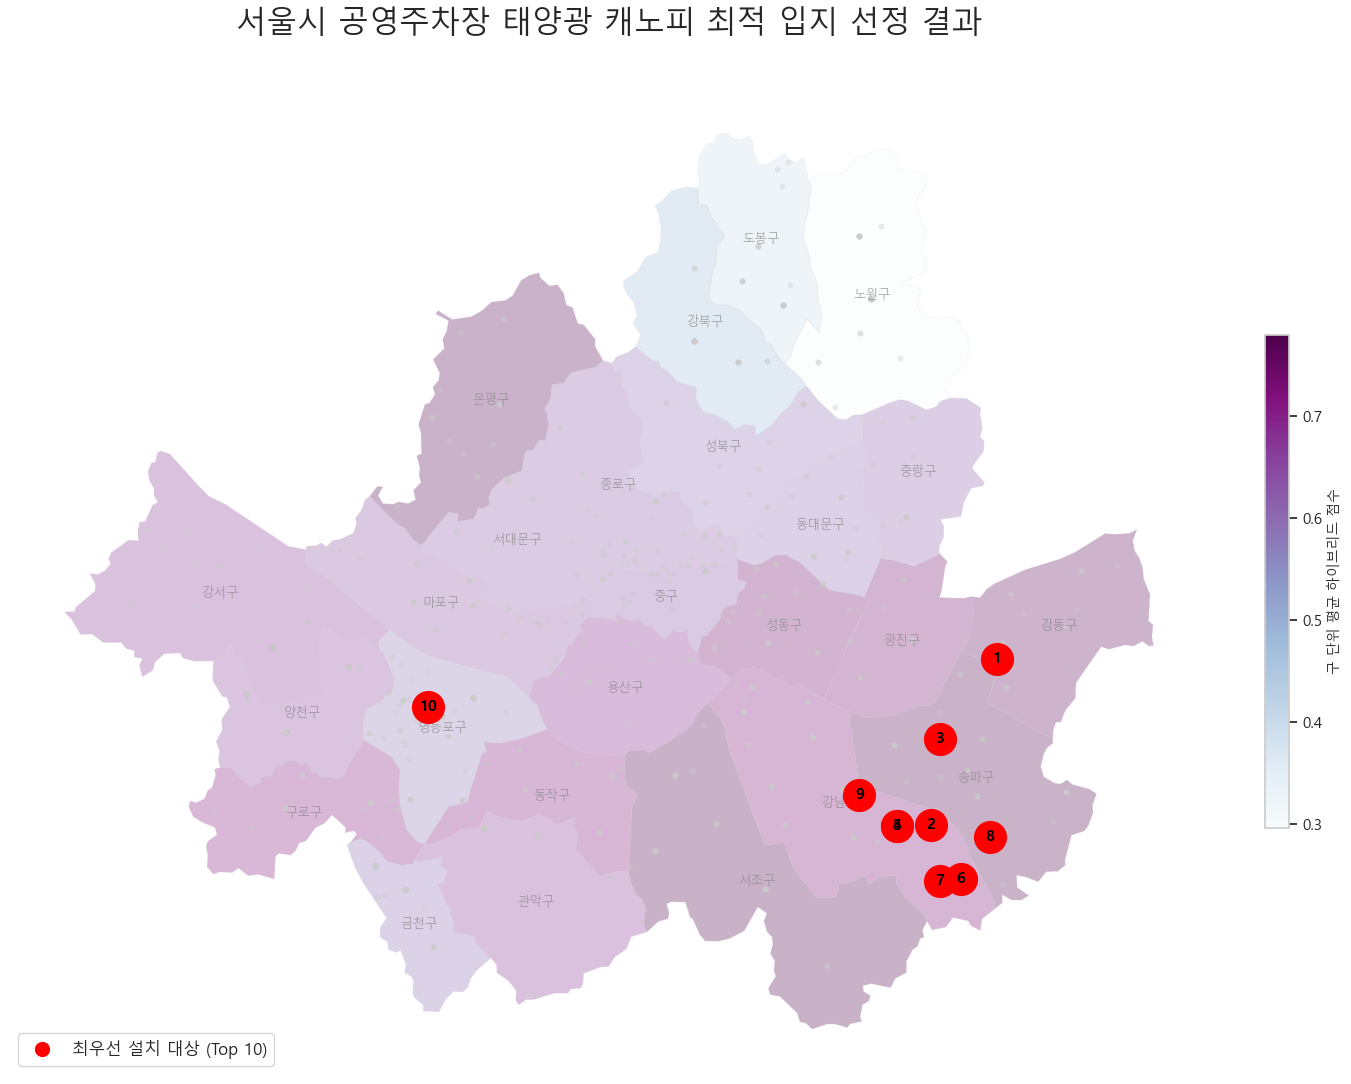

시각화 완료! 파일이 C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\최종_분석결과_지도_V2.png에 저장되었습니다.


In [39]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import requests
import warnings

warnings.filterwarnings('ignore')

# ── 1. 한글 폰트 및 환경 설정 ──────────────────────────────────
font_path = 'C:/Windows/Fonts/malgun.ttf'
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
font_bold = fm.FontProperties(fname=font_path, weight='bold')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# ── 2. 데이터 로드 및 전처리 ────────────────────────────────────
# df_hybrid에 이미 '자치구', 'lot', 'lat'이 포함되어 있으므로 이를 직접 사용합니다.
df_final = pd.read_csv(r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\data\final_output\final_result_hybrid.csv')

# 컬럼명 앞뒤 공백 제거 및 문자열 정제
df_final.columns = df_final.columns.str.strip()
if '자치구' in df_final.columns:
    df_final['자치구'] = df_final['자치구'].astype(str).str.strip()

# 자치구별 평균 점수 집계 (지도 배경용)
gu_score = df_final.groupby('자치구')['final_hybrid_score'].mean().reset_index()

# ── 3. 지리 데이터(GeoJSON) 결합 ───────────────────────────────
url = "https://raw.githubusercontent.com/southkorea/seoul-maps/master/kostat/2013/json/seoul_municipalities_geo_simple.json"
geo = gpd.read_file(requests.get(url).text)

# 배경 지도의 'name'과 데이터의 '자치구' 매칭
geo = geo.merge(gu_score, left_on='name', right_on='자치구', how='left')

# ── 4. 시각화 구현 ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 11))
fig.patch.set_facecolor('white')

# (1) 배경: 자치구별 코로플레스 (BuPu 스타일)
vmin, vmax = gu_score['final_hybrid_score'].min(), gu_score['final_hybrid_score'].max()
geo.plot(ax=ax, column='final_hybrid_score', cmap='BuPu', 
         edgecolor='#DDDDDD', linewidth=0.5, alpha=0.3)

# 자치구 이름 표시 (지도 중심부)
for _, row in geo.iterrows():
    if row.geometry is None: continue
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, row['name'], ha='center', va='center',
            fontproperties=font_prop, fontsize=9, color='#888888', alpha=0.7)

# (2) 전체 주차장 분포 (회색 점)
ax.scatter(df_final['lot'], df_final['lat'], s=10, color='#CCCCCC', alpha=0.3, zorder=1)

# (3) 상위 10개 입지 순위 핀 마킹 (핵심 포인트)
top_10 = df_final.nlargest(10, 'final_hybrid_score').reset_index(drop=True)

for i, row in top_10.iterrows():
    rank = i + 1
    # 빨간색 핀 배경
    ax.scatter(row['lot'], row['lat'], s=500, color='#FF0000', 
               linewidths=1.5, alpha=1.0, zorder=10)
    
    # 핀 내부 숫자
    ax.text(row['lot'], row['lat'], str(rank),
            va='center', ha='center',
            color='black', fontweight='bold', fontsize=11,
            zorder=11)

# ── 5. 디자인 및 범례 설정 ─────────────────────────────────────
# 컬러바 추가
sm = cm.ScalarMappable(cmap='BuPu', norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.04, shrink=0.5)
cbar.set_label('구 단위 평균 하이브리드 점수', fontproperties=font_prop, fontsize=10)

# 커스텀 범례
ax.legend([plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF0000', markersize=12)],
          ['최우선 설치 대상 (Top 10)'], prop=font_bold, loc='lower left', frameon=True)

plt.title('서울시 공영주차장 태양광 캐노피 최적 입지 선정 결과', 
          fontproperties=font_bold, fontsize=22, pad=40)

ax.set_axis_off()
plt.tight_layout()

# 저장 경로 확인 후 출력
save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\최종_분석결과_지도_V2.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"시각화 완료! 파일이 {save_path}에 저장되었습니다.")

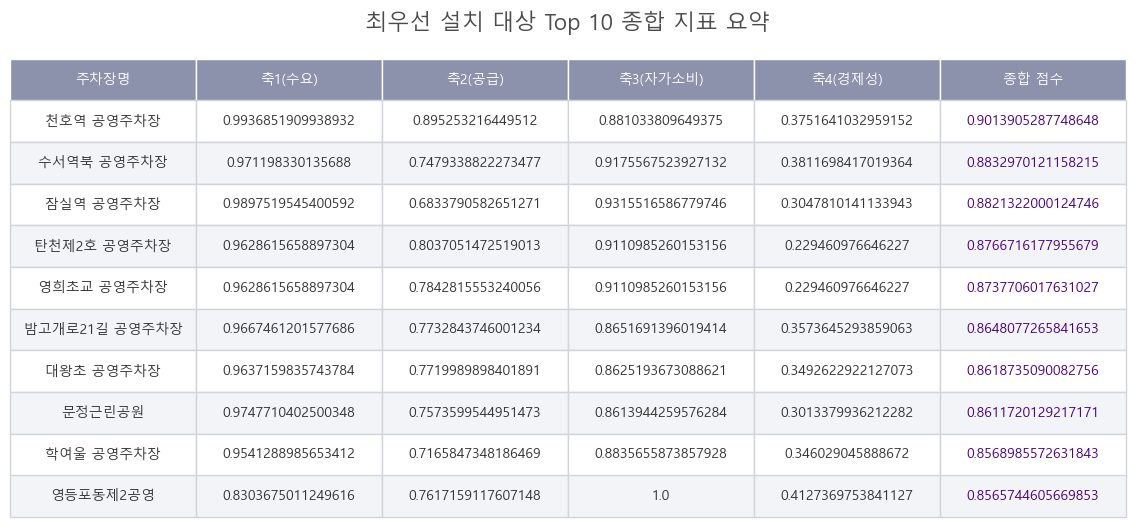

요약 표 생성 완료! 경로: C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_상위10개_요약표.png


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 준비 (상위 10개)
top_10_table = df_final.nlargest(10, 'final_hybrid_score')[
    ['pklt_nm', '축1_score', '축2_score', '축3_score', '축4_score', 'final_hybrid_score']
].copy()

# 컬럼명 정리
top_10_table.columns = ['주차장명', '축1(수요)', '축2(공급)', '축3(자가소비)', '축4(경제성)', '종합 점수']

# 2. 시각화 설정
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

# 3. 테이블 생성
table = ax.table(
    cellText=top_10_table.values,
    colLabels=top_10_table.columns,
    loc='center',
    cellLoc='center'
)

# 4. BuPu 스타일 디자인 입히기 (연보라 + 흰색)
header_color = '#8C92AC'  # 차분한 연보라 (BuPu 계열)
row_colors = ['#F3F4F7', 'white']  # 줄무늬 효과 (Zebra striping)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2.5)  # 표 간격 확대

for (i, j), cell in table.get_celld().items():
    # 헤더 설정
    if i == 0:
        cell.set_text_props(fontproperties=font_bold, color='white')
        cell.set_facecolor(header_color)
        cell.set_edgecolor('white')
    # 데이터 행 설정
    else:
        cell.set_text_props(fontproperties=font_prop, color='#333333')
        cell.set_facecolor(row_colors[i % 2])
        cell.set_edgecolor('#D1D5DB')
        
        # 종합 점수 컬럼(마지막 열) 강조
        if j == 5:
            cell.set_text_props(fontproperties=font_bold, color='#4B0082') # 진한 보라색 강조

plt.title('최우선 설치 대상 Top 10 종합 지표 요약', 
          fontproperties=font_bold, fontsize=16, pad=20, color='#4B4B4B')

# 저장
save_path_table = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_상위10개_요약표.png'
plt.savefig(save_path_table, dpi=300, bbox_inches='tight')
plt.show()

print(f"요약 표 생성 완료! 경로: {save_path_table}")

NameError: name 'font_prop' is not defined

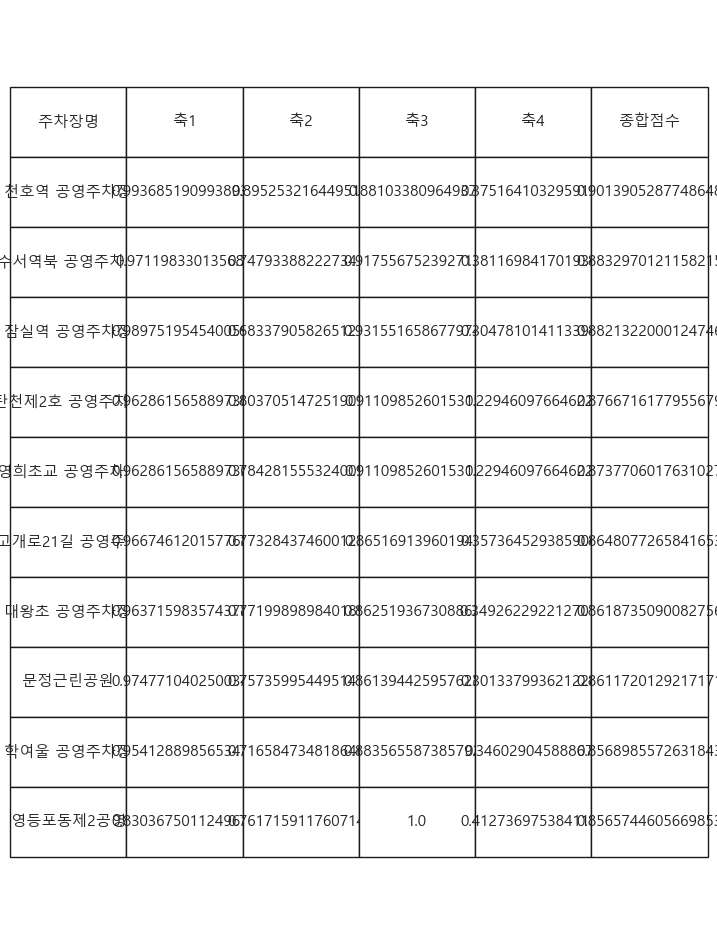

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 준비
top_10_table = df_final.nlargest(10, 'final_hybrid_score')[
    ['pklt_nm', '축1_score', '축2_score', '축3_score', '축4_score', 'final_hybrid_score']
].copy()

top_10_table.columns = ['주차장명', '축1', '축2', '축3', '축4', '종합점수']

# 2. 시각화 설정 (3:4 비율 유도를 위해 가로를 줄이고 세로를 늘림)
# figsize=(가로, 세로) 비율을 약 3:4에 가깝게 설정 (9:12 비율)
fig, ax = plt.subplots(figsize=(9, 12))
ax.axis('off')

# 3. 테이블 생성
table = ax.table(
    cellText=top_10_table.values,
    colLabels=top_10_table.columns,
    loc='center',
    cellLoc='center'
)

# 4. BuPu 스타일 및 레이아웃 조정
header_color = '#8C92AC' 
row_colors = ['#F8F9FB', 'white'] 

table.auto_set_font_size(False)
table.set_fontsize(11)

# scale(가로폭, 세로높이): 세로 높이를 더 키워 3:4 느낌을 강조
table.scale(1.0, 4.2) 

for (i, j), cell in table.get_celld().items():
    # 헤더 디자인
    if i == 0:
        cell.set_text_props(fontproperties=font_bold, color='white', fontsize=12)
        cell.set_facecolor(header_color)
        cell.set_edgecolor('white')
    # 데이터 행 디자인
    else:
        cell.set_text_props(fontproperties=font_prop, color='#333333')
        cell.set_facecolor(row_colors[i % 2])
        cell.set_edgecolor('#E5E7EB')
        
        # 마지막 종합점수 열 강조
        if j == 5:
            cell.set_text_props(fontproperties=font_bold, color='#4B0082')

# 제목 추가
plt.title('상위 10개 입지 분석 요약 (Top 10 Profile)', 
          fontproperties=font_bold, fontsize=18, pad=30, color='#333333')

plt.tight_layout()

# 저장
save_path_v_table = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_상위10개_세로표_3_4.png'
plt.savefig(save_path_v_table, dpi=300, bbox_inches='tight')
plt.show()

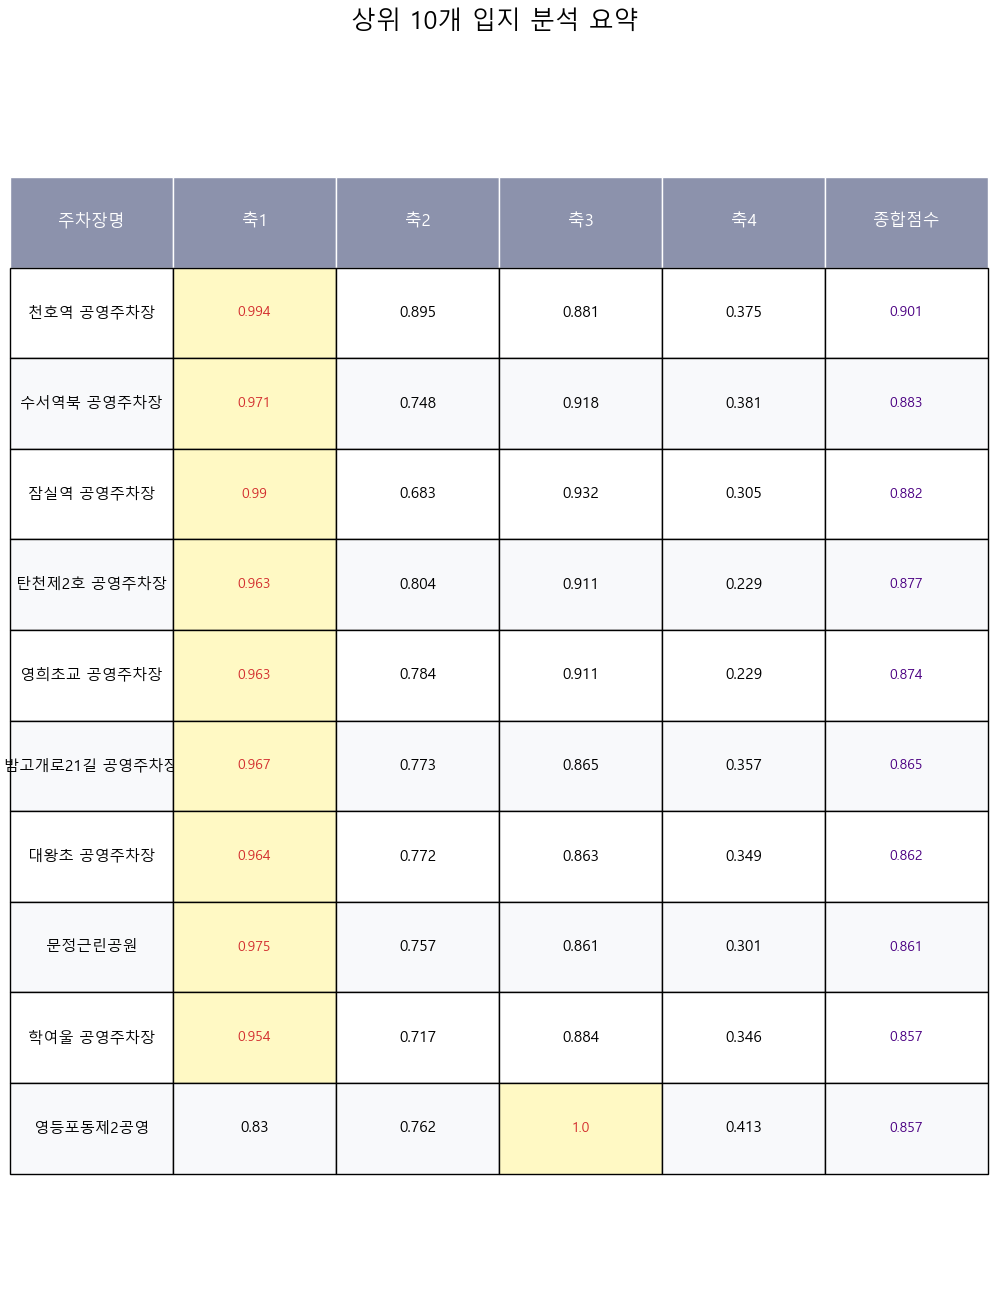

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비 및 소수점 3자리 반올림
top_10_table = df_final.nlargest(10, 'final_hybrid_score')[
    ['pklt_nm', '축1_score', '축2_score', '축3_score', '축4_score', 'final_hybrid_score']
].copy()

# 데이터 수치 정리
for col in ['축1_score', '축2_score', '축3_score', '축4_score', 'final_hybrid_score']:
    top_10_table[col] = top_10_table[col].round(3)

top_10_table.columns = ['주차장명', '축1', '축2', '축3', '축4', '종합점수']

# 2. 시각화 설정 (3:4 비율 유지)
fig, ax = plt.subplots(figsize=(10, 13))
ax.axis('off')

# 3. 테이블 생성
table = ax.table(
    cellText=top_10_table.values,
    colLabels=top_10_table.columns,
    loc='center',
    cellLoc='center'
)

# 4. 스타일 및 행별 최댓값 강조 로직
header_color = '#8C92AC'  # 연보라 헤더
highlight_color = '#E1F5FE' # 강조색: 아주 연한 블루 (눈에 띄는 색)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 4.5) # 가독성을 위해 세로폭 확장

# 데이터 셀 순회하며 강조 적용
for i in range(len(top_10_table)):
    # 각 행(주차장)에서 축1~축4(인덱스 1~4) 중 가장 큰 값 찾기
    row_values = top_10_table.iloc[i, 1:5].values
    max_val = np.max(row_values)
    
    for j in range(len(top_10_table.columns)):
        cell = table[i+1, j] # i+1인 이유는 헤더가 0번 행이라서
        
        # 헤더 디자인
        if i == -1: # (이 루프에선 처리 안됨, 아래 별도 처리)
            pass
        else:
            # 기본 배경색 (줄무늬)
            bg_color = '#F8F9FB' if (i+1) % 2 == 0 else 'white'
            cell.set_facecolor(bg_color)
            
            # 축 점수 컬럼(1~4번 열)에서 최댓값인 경우 강조색 입히기
            if 1 <= j <= 4 and top_10_table.iloc[i, j] == max_val:
                cell.set_facecolor('#FFF9C4') # 강조색: 연한 노란색 (눈에 확 띔)
                cell.set_text_props(fontproperties=font_bold, color='#D32F2F') # 글자도 붉은색 볼드
                
            # 마지막 종합점수 열 글자 강조
            if j == 5:
                cell.set_text_props(fontproperties=font_bold, color='#4B0082')

# 헤더 별도 디자인 적용
for j in range(len(top_10_table.columns)):
    cell = table[0, j]
    cell.set_text_props(fontproperties=font_bold, color='white', fontsize=12)
    cell.set_facecolor(header_color)
    cell.set_edgecolor('white')

plt.title('상위 10개 입지 분석 요약 ', 
          fontproperties=font_bold, fontsize=18, pad=30)

plt.tight_layout()
save_path_final_table = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_상위10개_강조표.png'
plt.savefig(save_path_final_table, dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# 시각화 스타일 설정
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

NameError: name 'font_bold' is not defined

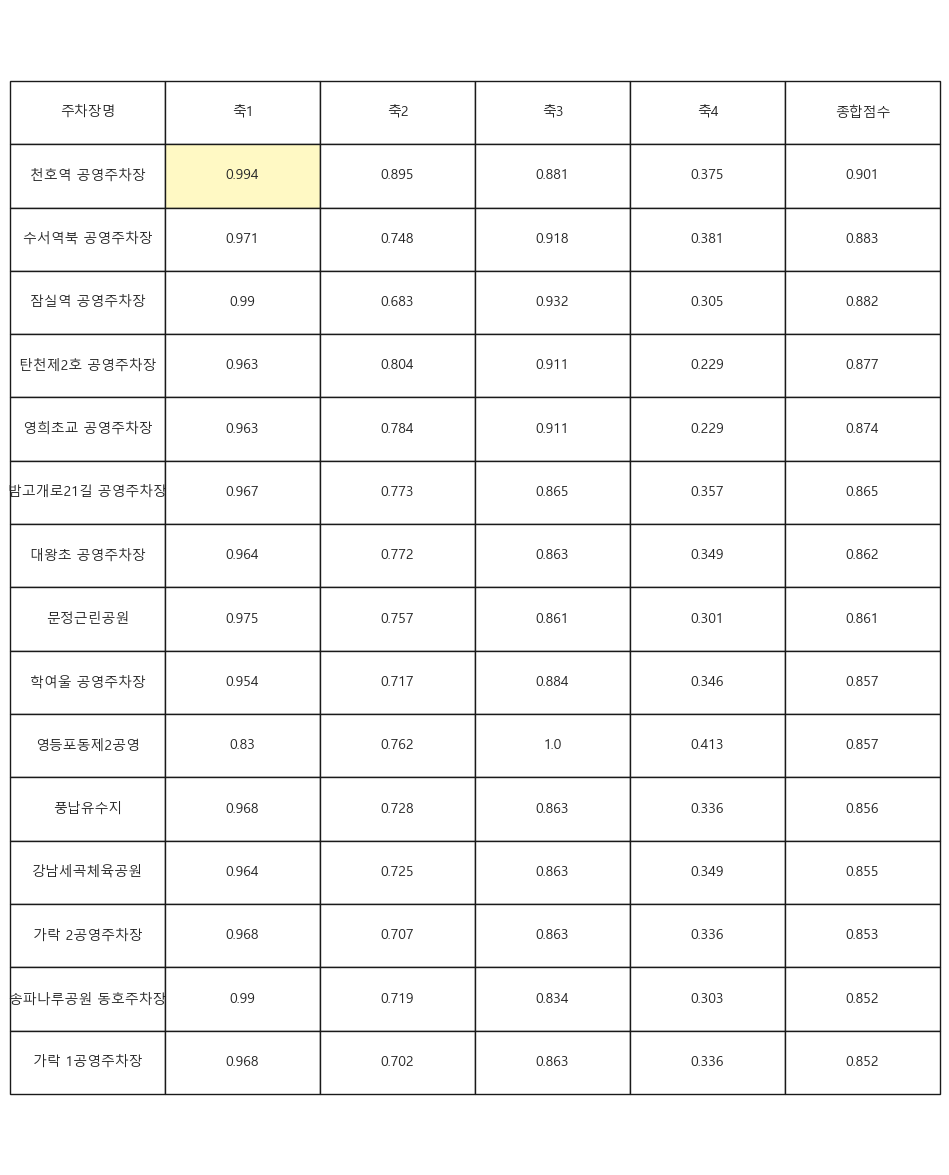

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비 및 수치 정리 (상위 15개)
top_15_table = df_final.nlargest(15, 'final_hybrid_score')[
    ['pklt_nm', '축1_score', '축2_score', '축3_score', '축4_score', 'final_hybrid_score']
].copy()

# 소수점 3자리 반올림
for col in ['축1_score', '축2_score', '축3_score', '축4_score', 'final_hybrid_score']:
    top_15_table[col] = top_15_table[col].round(3)

top_15_table.columns = ['주차장명', '축1', '축2', '축3', '축4', '종합점수']

# 2. 시각화 설정 (15행을 수용하기 위해 세로 길이를 15로 조정)
fig, ax = plt.subplots(figsize=(10, 15))
ax.axis('off')

# 3. 테이블 생성
table = ax.table(
    cellText=top_15_table.values,
    colLabels=top_15_table.columns,
    loc='center',
    cellLoc='center'
)

# 4. 스타일링 및 동적 강조 설정
header_color = '#8C92AC'   # 연보라 헤더
highlight_bg = '#FFF9C4'   # 강조 배경 (연한 노랑)
highlight_text = '#D32F2F' # 강조 글자 (빨간색)

table.auto_set_font_size(False)
table.set_fontsize(10)      # 행이 늘어났으므로 폰트 크기 살짝 축소
table.scale(1.2, 3.8)      # 행 높이 조절

# 테이블 셀 속성 변경
for i in range(len(top_15_table)):
    # 해당 행의 축 점수(1~4열) 중 최댓값 계산
    row_scores = top_15_table.iloc[i, 1:5].values
    max_score = np.max(row_scores)
    
    for j in range(len(top_15_table.columns)):
        cell = table[i+1, j]
        
        # 기본 배경색 (줄무늬 효과)
        bg_color = '#F8F9FB' if (i+1) % 2 == 0 else 'white'
        cell.set_facecolor(bg_color)
        
        # [강조] 축 점수 중 최고점인 칸 하이라이트
        if 1 <= j <= 4 and top_15_table.iloc[i, j] == max_score:
            cell.set_facecolor(highlight_bg)
            cell.set_text_props(fontproperties=font_bold, color=highlight_text)
            
        # [강조] 종합점수 열 볼드 처리
        if j == 5:
            cell.set_text_props(fontproperties=font_bold, color='#4B0082')

# 헤더 디자인 적용
for j in range(len(top_15_table.columns)):
    cell = table[0, j]
    cell.set_text_props(fontproperties=font_bold, color='white', fontsize=11)
    cell.set_facecolor(header_color)
    cell.set_edgecolor('white')

plt.title('상위 15개 최적 입지 지표 분석 요약', 
          fontproperties=font_bold, fontsize=18, pad=30)

plt.tight_layout()

# 5. 저장
save_path_top15 = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_상위15개_강조표.png'
plt.savefig(save_path_top15, dpi=300, bbox_inches='tight')
plt.show()

### 시각화2 - 4축점수 히트맵

목적: 어떤 주차장이 어느 축에서 강한지

**전략**:
1. 대상 선정: 최종 하이브리드 점수 기준 상위 15개소를 선정합니다.

2. 데이터 구성: 행(Index)은 주차장명, 열(Column)은 4개의 평가 축 점수로 구성합니다.

3. 컬러맵 (YlGnBu): 기획안의 요청대로 색상 차이로 즉시 패턴이 읽히도록 노랑-초록-파랑 계열을 사용합니다.

4. 가독성: 점수 수치를 칸 안에 표시(annot=True)하여 정밀한 비교가 가능하게 합니다.

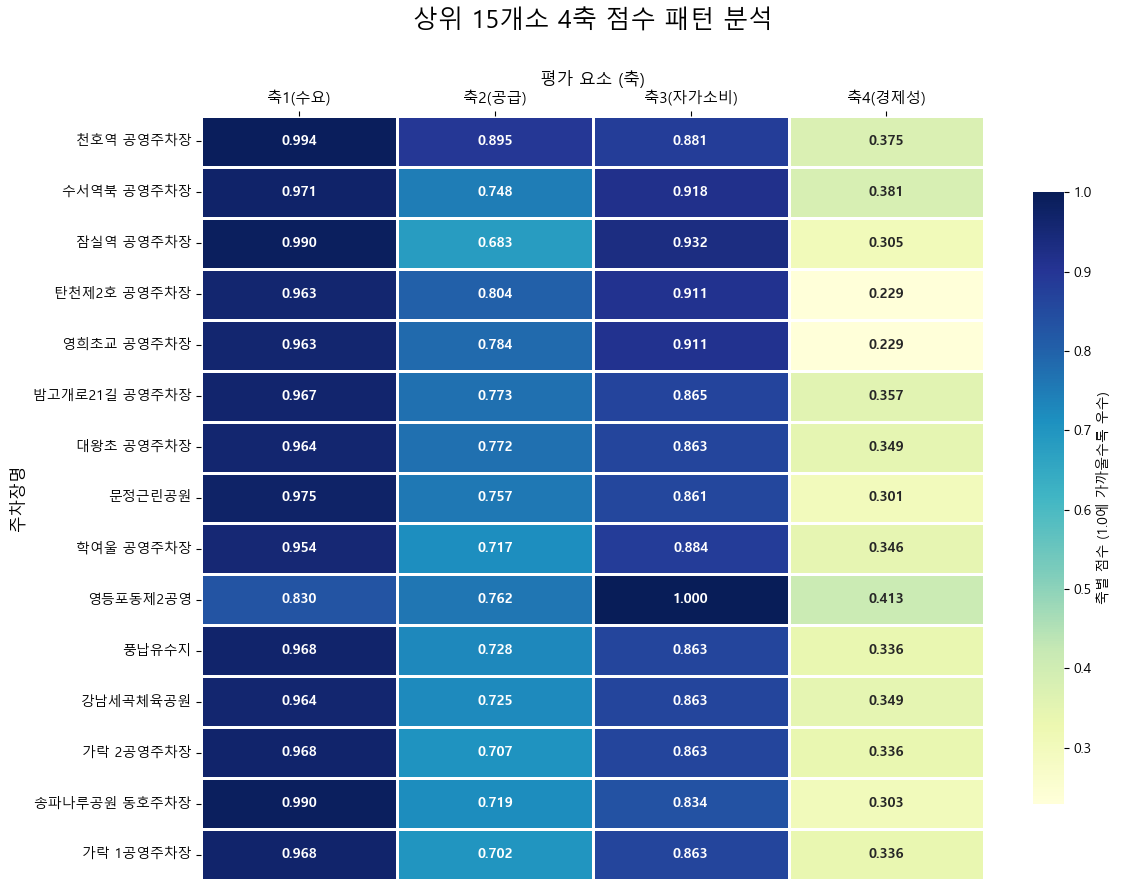

히트맵 수정 완료! 경로: C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_4축_히트맵_YlGnBu.png


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 1. 데이터 준비 ──────────────────────────────────────────
# 상위 15개 주차장 추출
top_15_heat = df_final.nlargest(15, 'final_hybrid_score')

# 히트맵용 데이터 가공
heatmap_data = top_15_heat.set_index('pklt_nm')[['축1_score', '축2_score', '축3_score', '축4_score']]

# 축 이름 변경 (기획안의 의미에 맞게 매핑)
# 축1: 수요/인프라, 축2: 공급/규모, 축3: 자가소비(태양광), 축4: 경제성/효율
heatmap_data.columns = ['축1(수요)', '축2(공급)', '축3(자가소비)', '축4(경제성)']

# ── 2. 히트맵 시각화 ────────────────────────────────────────
# figure 생성 시 바로 배경색을 지정합니다.
fig, ax = plt.subplots(figsize=(12, 9), facecolor='white')

# sns.heatmap 설정
sns.heatmap(heatmap_data, 
            annot=True, 
            cmap='YlGnBu', 
            fmt='.3f', 
            linewidths=0.8, 
            linecolor='white',
            cbar_kws={'label': '축별 점수 (1.0에 가까울수록 우수)', 'shrink': 0.8},
            annot_kws={"size": 10, "weight": "bold"},
            ax=ax)

# ── 3. 디자인 디테일 ────────────────────────────────────────
# 제목 설정
ax.set_title('상위 15개소 4축 점수 패턴 분석', 
             fontproperties=font_bold, fontsize=18, pad=30)

# 축 레이블 설정
ax.set_ylabel('주차장명', fontproperties=font_prop, fontsize=12)
ax.set_xlabel('평가 요소 (축)', fontproperties=font_prop, fontsize=12)

# X축 라벨을 위로 옮겨서 시선이 제목과 바로 이어지게 함
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# 폰트 적용
plt.xticks(fontproperties=font_prop, fontsize=11)
plt.yticks(fontproperties=font_prop, fontsize=10)

plt.tight_layout()

# 저장 및 출력
save_path_heat = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_4축_히트맵_YlGnBu.png'
plt.savefig(save_path_heat, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"히트맵 수정 완료! 경로: {save_path_heat}")

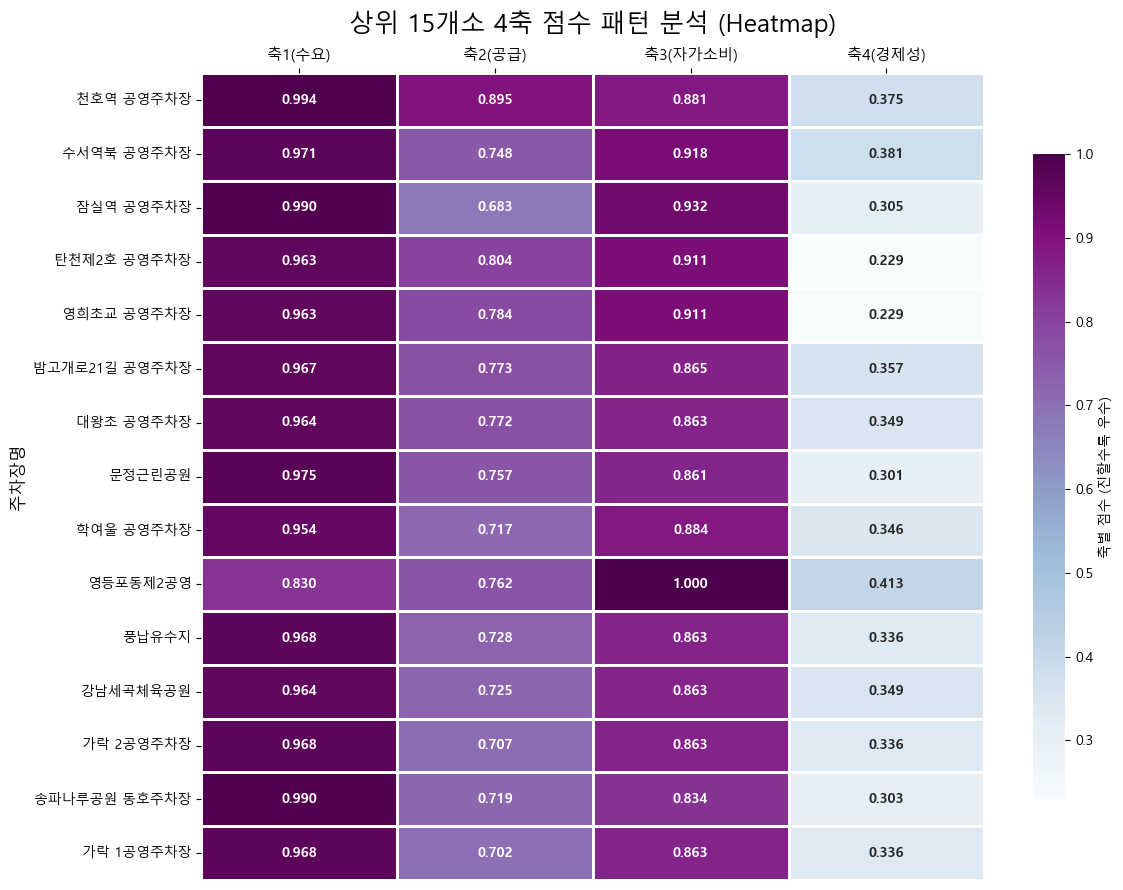

BuPu 히트맵 생성 완료! 지도와 통일감이 부여되었습니다. 경로: C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_4축_히트맵_BuPu.png


In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 1. 데이터 준비 ──────────────────────────────────────────
# 상위 15개 주차장 추출
top_15_heat = df_final.nlargest(15, 'final_hybrid_score')

# 히트맵용 데이터 가공 (축별 점수 선택)
heatmap_data = top_15_heat.set_index('pklt_nm')[['축1_score', '축2_score', '축3_score', '축4_score']]

# 축 이름을 가독성 있게 변경
heatmap_data.columns = ['축1(수요)', '축2(공급)', '축3(자가소비)', '축4(경제성)']

# ── 2. 히트맵 시각화 ────────────────────────────────────────
# 지도와 동일한 톤을 유지하기 위해 배경색 흰색 설정
fig, ax = plt.subplots(figsize=(12, 9), facecolor='white')

# sns.heatmap 설정
# cmap='BuPu' : 연한 파랑(낮음) -> 진한 보라(높음)
sns.heatmap(heatmap_data, 
            annot=True, 
            cmap='BuPu', 
            fmt='.3f', 
            linewidths=1.0, 
            linecolor='white', # 칸 사이 구분선을 흰색으로 주어 깔끔하게 표현
            cbar_kws={'label': '축별 점수 (진할수록 우수)', 'shrink': 0.8},
            annot_kws={"size": 10, "weight": "bold"},
            ax=ax)

# ── 3. 디자인 디테일 (슬라이드 1 오른쪽 최적화) ────────────────
# 제목 설정
ax.set_title('상위 15개소 4축 점수 패턴 분석 (Heatmap)', 
             fontproperties=font_bold, fontsize=18, pad=30)

# 축 레이블 설정 및 위치 조정
ax.set_ylabel('주차장명', fontproperties=font_prop, fontsize=12)
ax.xaxis.tick_top() # X축 라벨을 위로
ax.xaxis.set_label_position('top')

# 폰트 적용
plt.xticks(fontproperties=font_prop, fontsize=11)
plt.yticks(fontproperties=font_prop, fontsize=10)

plt.tight_layout()

# 저장 및 출력
save_path_heat = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_4축_히트맵_BuPu.png'
plt.savefig(save_path_heat, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"BuPu 히트맵 생성 완료! 지도와 통일감이 부여되었습니다. 경로: {save_path_heat}")

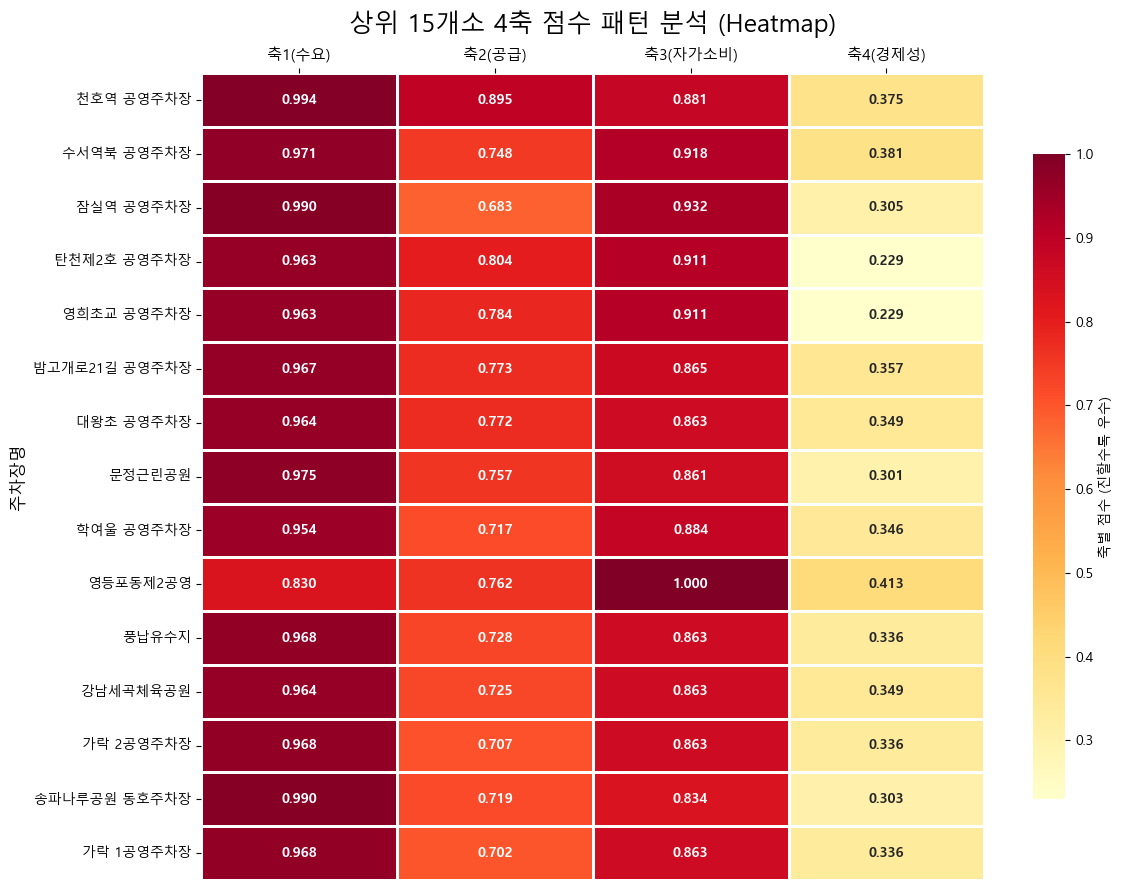

BuPu 히트맵 생성 완료! 지도와 통일감이 부여되었습니다. 경로: C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_4축_히트맵_YlOrRd.png


In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 1. 데이터 준비 ──────────────────────────────────────────
# 상위 15개 주차장 추출
top_15_heat = df_final.nlargest(15, 'final_hybrid_score')

# 히트맵용 데이터 가공 (축별 점수 선택)
heatmap_data = top_15_heat.set_index('pklt_nm')[['축1_score', '축2_score', '축3_score', '축4_score']]

# 축 이름을 가독성 있게 변경
heatmap_data.columns = ['축1(수요)', '축2(공급)', '축3(자가소비)', '축4(경제성)']

# ── 2. 히트맵 시각화 ────────────────────────────────────────
# 지도와 동일한 톤을 유지하기 위해 배경색 흰색 설정
fig, ax = plt.subplots(figsize=(12, 9), facecolor='white')

# sns.heatmap 설정
# cmap='BuPu' : 연한 파랑(낮음) -> 진한 보라(높음)
sns.heatmap(heatmap_data, 
            annot=True, 
            cmap='YlOrRd', 
            fmt='.3f', 
            linewidths=1.0, 
            linecolor='white', # 칸 사이 구분선을 흰색으로 주어 깔끔하게 표현
            cbar_kws={'label': '축별 점수 (진할수록 우수)', 'shrink': 0.8},
            annot_kws={"size": 10, "weight": "bold"},
            ax=ax)

# ── 3. 디자인 디테일 (슬라이드 1 오른쪽 최적화) ────────────────
# 제목 설정
ax.set_title('상위 15개소 4축 점수 패턴 분석 (Heatmap)', 
             fontproperties=font_bold, fontsize=18, pad=30)

# 축 레이블 설정 및 위치 조정
ax.set_ylabel('주차장명', fontproperties=font_prop, fontsize=12)
ax.xaxis.tick_top() # X축 라벨을 위로
ax.xaxis.set_label_position('top')

# 폰트 적용
plt.xticks(fontproperties=font_prop, fontsize=11)
plt.yticks(fontproperties=font_prop, fontsize=10)

plt.tight_layout()

# 저장 및 출력
save_path_heat = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_4축_히트맵_YlOrRd.png'
plt.savefig(save_path_heat, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"BuPu 히트맵 생성 완료! 지도와 통일감이 부여되었습니다. 경로: {save_path_heat}")

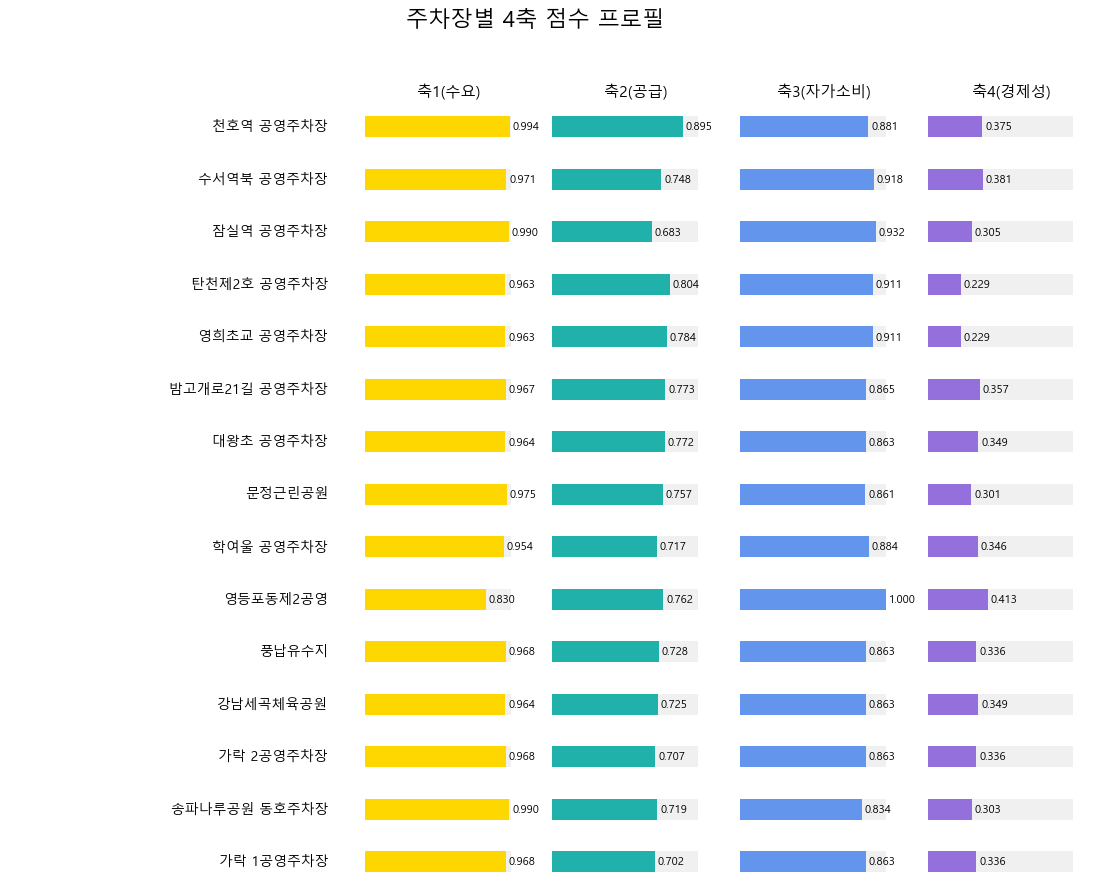

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비 (상위 15개)
top_15 = df_final.nlargest(15, 'final_hybrid_score').copy()
cols = ['축1_score', '축2_score', '축3_score', '축4_score']
col_names = ['축1(수요)', '축2(공급)', '축3(자가소비)', '축4(경제성)']

# 2. 시각화 설정
num_rows = len(top_15)
num_cols = len(cols)

fig, axes = plt.subplots(num_rows, num_cols + 1, figsize=(14, 10), 
                         gridspec_kw={'width_ratios': [2, 1, 1, 1, 1]})
fig.patch.set_facecolor('white')

# 컬러 설정 (기존 이미지의 톤 유지)
colors = ['#FFD700', '#20B2AA', '#6495ED', '#9370DB'] # 노랑, 녹색, 파랑, 보라

for i, (idx, row) in enumerate(top_15.iterrows()):
    # [열 0] 주차장 이름
    axes[i, 0].text(0.95, 0.5, row['pklt_nm'], va='center', ha='right', 
                    fontproperties=font_bold, fontsize=10)
    axes[i, 0].axis('off')
    
    # [열 1~4] 각 축별 게이지
    for j, col in enumerate(cols):
        ax = axes[i, j+1]
        score = row[col]
        
        # 배경 바 (최대 1.0)
        ax.barh(0, 1.0, color='#F0F0F0', height=0.6)
        # 실제 점수 바
        ax.barh(0, score, color=colors[j], height=0.6)
        
        # 수치 텍스트
        ax.text(score + 0.02, 0, f'{score:.3f}', va='center', 
                fontproperties=font_prop, fontsize=8)
        
        ax.set_xlim(0, 1.15) # 텍스트 공간 확보
        ax.set_ylim(-0.5, 0.5)
        ax.axis('off')

# 최상단에 컬럼 제목 추가
for j, name in enumerate(col_names):
    axes[0, j+1].set_title(name, fontproperties=font_bold, fontsize=11, pad=10)

plt.subplots_adjust(wspace=0.1, hspace=0.5)
plt.suptitle('주차장별 4축 점수 프로필', fontproperties=font_bold, fontsize=16, y=0.98)

save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\게이지형_결과표.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'font_bold' is not defined

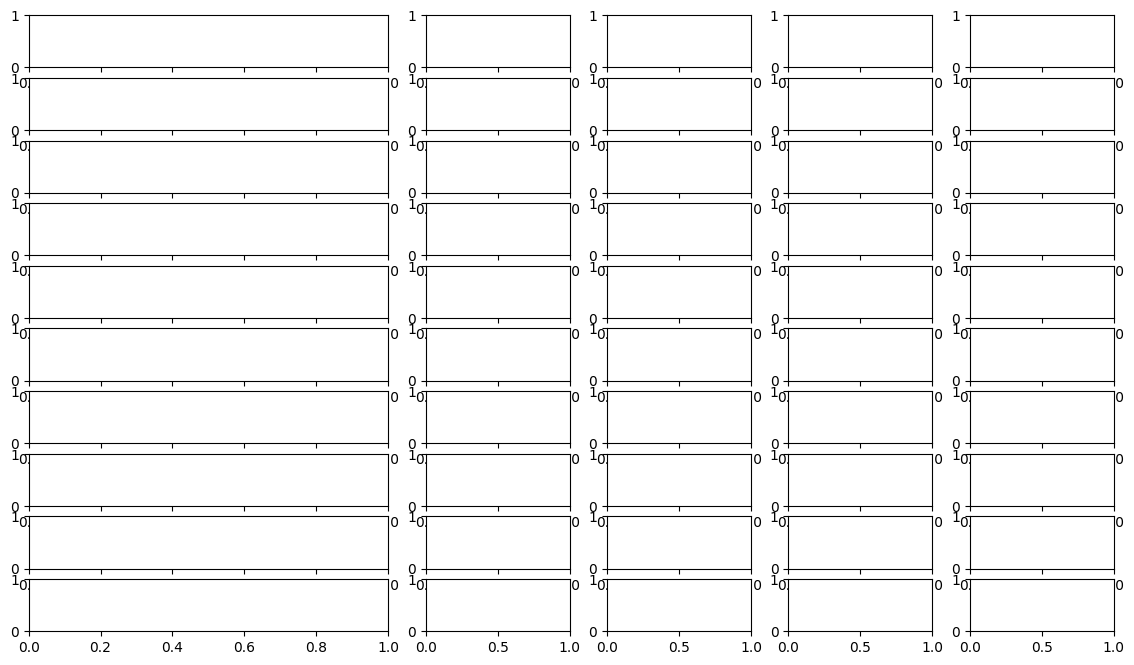

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 데이터 준비 (상위 10개로 축소)
top_10 = df_final.nlargest(10, 'final_hybrid_score').copy()
cols = ['축1_score', '축2_score', '축3_score', '축4_score']
col_names = ['축1 (수요)', '축2 (공급)', '축3 (자가소비)', '축4 (경제성)']

# 2. 세련된 컬러 팔레트 설정
colors = ['#4A90E2', '#5C6BC0', '#26A69A', '#78909C'] 

# 3. 시각화 설정
num_rows = len(top_10)
num_cols = len(cols)

# 행 간격을 조절하여 더 여유로운 레이아웃 생성
fig, axes = plt.subplots(num_rows, num_cols + 1, figsize=(14, 8), 
                         gridspec_kw={'width_ratios': [2.5, 1, 1, 1, 1]})
fig.patch.set_facecolor('white')

for i, (idx, row) in enumerate(top_10.iterrows()):
    # [열 0] 주차장 이름 (글자 크기 키우고 볼드 처리)
    axes[i, 0].text(0.9, 0.5, row['pklt_nm'], va='center', ha='right', 
                    fontproperties=font_bold, fontsize=12, color='#333333')
    axes[i, 0].axis('off')
    
    # [열 1~4] 각 축별 게이지
    for j, col in enumerate(cols):
        ax = axes[i, j+1]
        score = row[col]
        
        # 배경 바 (연한 그레이로 세련되게)
        ax.barh(0, 1.0, color='#E0E0E0', height=0.4, edgecolor='none')
        # 실제 점수 바 (추천 컬러 적용)
        ax.barh(0, score, color=colors[j], height=0.4, edgecolor='none')
        
        # 수치 텍스트 (바 바로 뒤에 작게 표시)
        ax.text(score + 0.03, 0, f'{score:.2f}', va='center', 
                fontproperties=font_prop, fontsize=9, color='#666666')
        
        ax.set_xlim(0, 1.2) 
        ax.set_ylim(-0.5, 0.5)
        ax.axis('off')

# 최상단 컬럼 제목 디자인
for j, name in enumerate(col_names):
    axes[0, j+1].set_title(name, fontproperties=font_bold, 
                           fontsize=11, color='#555555', pad=15)

# 전체 레이아웃 조정
plt.subplots_adjust(wspace=0.15, hspace=0.6)
plt.suptitle('최우선 설치 대상 Top 10 입지별 상세 프로필', 
             fontproperties=font_bold, fontsize=18, y=1.02, color='#222222')

save_path = r'C:\Users\seonu\Documents\axis3-self-consumption\canopy\output\figures\슬라이드1_우측_게이지차트_최종.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()